In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, differential_evolution
from scipy.stats import pearsonr
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

## Regression Analysis

In [2]:
# Define the three discounting models
def hyperbolic_model(delay, k):
    """
    Simple hyperbolic discounting model (Mazur, 1987)
    V = A / (1 + k*D)
    We'll normalize to A=1 for indifference points
    """
    return 1 / (1 + k * delay)

def green_myerson_hyperboloid(delay, k, s):
    """
    Green & Myerson hyperboloid model (1996)
    V = A / (1 + k*D)^s
    """
    return 1 / ((1 + k * delay) ** s)

def rachlin_hyperboloid(delay, k, s):
    """
    Rachlin's hyperboloid model (2006)
    V = A / (1 + k*D^s)
    """
    return 1 / (1 + k * (delay ** s))

def prepare_data_for_fitting(raw_data, participant_id, commodity=None):
    """
    Extract delay and indifference point data for a specific participant and commodity
    
    Parameters:
    - raw_data: DataFrame with the participant data
    - participant_id: ID of the participant to analyze
    - commodity: Specific commodity to analyze (e.g., 'Money', 'Money Loss', 'Health', 'Time')
                If None, will return data for all commodities
    """
    # Get participant data
    participant_data = raw_data[raw_data['participant_id'] == participant_id]
    
    if participant_data.empty:
        raise ValueError(f"Participant {participant_id} not found in data")
    
    # If specific commodity requested, filter for that
    if commodity is not None:
        participant_data = participant_data[participant_data['Commodity'] == commodity]
        if participant_data.empty:
            available_commodities = raw_data[raw_data['participant_id'] == participant_id]['Commodity'].unique()
            raise ValueError(f"Commodity '{commodity}' not found for participant {participant_id}. "
                           f"Available commodities: {list(available_commodities)}")
    
    # Extract delay columns (assuming they start with 'delay_')
    delay_columns = [col for col in raw_data.columns if col.startswith('delay_')]
    
    # Extract delays from column names
    delays = np.array([float(col.split('_')[1]) for col in delay_columns])
    
    results = {}
    
    # Process each commodity for this participant
    for _, row in participant_data.iterrows():
        commodity_name = row['Commodity']
        amount = row['Amount']
        
        # Extract indifference points for this commodity
        indifference_points = row[delay_columns].values
        
        # Convert to proportions (divide by amount to normalize)
        # This ensures all data is on 0-1 scale regardless of whether amount is 100 or 1000
        normalized_indifference_points = indifference_points / amount
        
        results[commodity_name] = {
            'delays': delays,
            'indifference_points': normalized_indifference_points,
            'raw_indifference_points': indifference_points,
            'amount': amount
        }
    
    # If only one commodity requested, return just that data
    if commodity is not None:
        commodity_data = results[commodity]
        return delays, commodity_data['indifference_points']
    
    # Otherwise return all data
    return results

def fit_model_robust(model_func, delays, indifference_points, param_bounds=None, max_attempts=5):
    """
    Robust model fitting with multiple attempts and parameter bounds
    """
    best_params = None
    best_r_squared = -np.inf
    best_predictions = None
    
    # Set default bounds if not provided
    if param_bounds is None:
        if model_func.__name__ == 'hyperbolic_model':
            param_bounds = [(1e-6, 10)]  # k bounds
        else:  # hyperboloid models
            param_bounds = [(1e-6, 10), (0.1, 5)]  # k and s bounds
    
    for attempt in range(max_attempts):
        try:
            # Use differential_evolution for global optimization
            def objective(params):
                try:
                    predictions = model_func(delays, *params)
                    # Return sum of squared errors
                    return np.sum((indifference_points - predictions) ** 2)
                except:
                    return 1e10
            
            result = differential_evolution(objective, param_bounds, seed=attempt)
            
            if result.success:
                params = result.x
                predictions = model_func(delays, *params)
                
                # Calculate R-squared
                ss_res = np.sum((indifference_points - predictions) ** 2)
                ss_tot = np.sum((indifference_points - np.mean(indifference_points)) ** 2)
                r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
                
                if r_squared > best_r_squared:
                    best_params = params
                    best_r_squared = r_squared
                    best_predictions = predictions
                    
        except Exception as e:
            continue
    
    return best_params, best_predictions, best_r_squared

def calculate_fit_metrics(observed, predicted, n_params, n_obs):
    """
    Calculate comprehensive fit metrics
    """
    # Basic calculations
    residuals = observed - predicted
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)
    
    # R-squared
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    # Mean Absolute Error
    mae = np.mean(np.abs(residuals))
    
    # Root Mean Square Error
    rmse = np.sqrt(np.mean(residuals ** 2))
    
    # Log-likelihood (assuming normal errors)
    mse = ss_res / n_obs
    log_likelihood = -0.5 * n_obs * (np.log(2 * np.pi * mse) + 1)
    
    # AIC and BIC
    aic = 2 * n_params - 2 * log_likelihood
    bic = np.log(n_obs) * n_params - 2 * log_likelihood
    
    # AICc (corrected AIC for small samples)
    if n_obs - n_params - 1 > 0:
        aicc = aic + (2 * n_params * (n_params + 1)) / (n_obs - n_params - 1)
    else:
        aicc = np.inf
    
    return {
        'R²': r_squared,
        'MAE': mae,
        'RMSE': rmse,
        'AIC': aic,
        'BIC': bic,
        'AICc': aicc,
        'Log_Likelihood': log_likelihood
    }

def analyze_participant(raw_data, participant_id, commodity=None, plot=True):
    """
    Complete analysis for a single participant and commodity
    
    Parameters:
    - raw_data: DataFrame with the participant data
    - participant_id: ID of the participant to analyze
    - commodity: Specific commodity to analyze. If None, will analyze all available commodities
    - plot: Whether to create plots
    """
    
    # Get available commodities for this participant
    participant_info = raw_data[raw_data['participant_id'] == participant_id]
    if participant_info.empty:
        print(f"Participant {participant_id} not found in data")
        return None, None, None
    
    available_commodities = participant_info['Commodity'].unique()
    
    if commodity is not None:
        if commodity not in available_commodities:
            print(f"Commodity '{commodity}' not available for participant {participant_id}")
            print(f"Available commodities: {list(available_commodities)}")
            return None, None, None
        commodities_to_analyze = [commodity]
    else:
        commodities_to_analyze = available_commodities
    
    all_results = {}
    
    for comm in commodities_to_analyze:
        # Get amount for this commodity
        comm_data = participant_info[participant_info['Commodity'] == comm]
        amount = comm_data['Amount'].iloc[0]
        
        print(f"\nAnalyzing Participant {participant_id} - {comm} (Amount: {amount})")
        print("=" * 60)
        
        # Prepare data for this specific commodity
        delays, indifference_points = prepare_data_for_fitting(raw_data, participant_id, comm)
        
        # Define models and their parameter bounds
        models = {
            'Hyperbolic': {
                'func': hyperbolic_model,
                'bounds': [(1e-6, 10)],
                'n_params': 1
            },
            'Green-Myerson': {
                'func': green_myerson_hyperboloid,
                'bounds': [(1e-6, 10), (0.1, 5)],
                'n_params': 2
            },
            'Rachlin': {
                'func': rachlin_hyperboloid,
                'bounds': [(1e-6, 10), (0.1, 5)],
                'n_params': 2
            }
        }
        
        results = {}
        
        # Fit each model
        for model_name, model_info in models.items():
            print(f"Fitting {model_name} model...")
            
            params, predictions, r_squared = fit_model_robust(
                model_info['func'], 
                delays, 
                indifference_points, 
                model_info['bounds']
            )
            
            if params is not None:
                # Calculate metrics
                metrics = calculate_fit_metrics(
                    indifference_points, 
                    predictions, 
                    model_info['n_params'], 
                    len(indifference_points)
                )
                
                results[model_name] = {
                    'params': params,
                    'predictions': predictions,
                    'metrics': metrics
                }
            else:
                print(f"Failed to fit {model_name} model")
        
        all_results[comm] = {
            'results': results,
            'amount': amount
        }
        
        # Create comparison plot for this commodity
        if plot and results:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
            
            # Plot 1: Data and model fits
            ax1.scatter(delays, indifference_points, color='black', s=50, 
                       label='Data', zorder=3)
            
            colors = ['red', 'blue', 'green']
            smooth_delays = np.linspace(0, max(delays), 100)
            
            for i, (model_name, result) in enumerate(results.items()):
                model_info = models[model_name]
                smooth_predictions = model_info['func'](smooth_delays, *result['params'])
                ax1.plot(smooth_delays, smooth_predictions, 
                        color=colors[i], linewidth=2, 
                        label=f"{model_name} (R² = {result['metrics']['R²']:.3f})")
            
            ax1.set_xlabel('Delay')
            ax1.set_ylabel('Indifference Point (Proportion)')
            ax1.set_title(f'Model Fits - Participant {participant_id} - {comm} (Amount: {amount})')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Plot 2: Fit metrics comparison
            metrics_to_plot = ['R²', 'MAE', 'RMSE']
            model_names = list(results.keys())
            
            x_pos = np.arange(len(model_names))
            width = 0.25
            
            for i, metric in enumerate(metrics_to_plot):
                values = [results[model]['metrics'][metric] for model in model_names]
                ax2.bar(x_pos + i*width, values, width, label=metric, alpha=0.8)
            
            ax2.set_xlabel('Model')
            ax2.set_ylabel('Metric Value')
            ax2.set_title(f'Fit Metrics Comparison - {comm}')
            ax2.set_xticks(x_pos + width)
            ax2.set_xticklabels(model_names)
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    
    return all_results, delays, indifference_points

def create_results_table(results, amount=None):
    """
    Create a comprehensive table of all fit metrics
    """
    if not results:
        print("No successful model fits to display")
        return None
    
    # Create DataFrame
    table_data = []
    for model_name, result in results.items():
        row = {'Model': model_name}
        if amount is not None:
            row['Amount'] = amount
        row.update(result['metrics'])
        
        # Add parameter values
        if model_name == 'Hyperbolic':
            row['k'] = result['params'][0]
            row['s'] = 'N/A'
        else:
            row['k'] = result['params'][0]
            row['s'] = result['params'][1]
        
        table_data.append(row)
    
    df = pd.DataFrame(table_data)
    
    # Reorder columns for better presentation
    base_columns = ['Model', 'k', 's', 'R²', 'MAE', 'RMSE', 'AIC', 'BIC', 'AICc', 'Log_Likelihood']
    if amount is not None:
        column_order = ['Model', 'Amount', 'k', 's', 'R²', 'MAE', 'RMSE', 'AIC', 'BIC', 'AICc', 'Log_Likelihood']
    else:
        column_order = base_columns
    
    # Only include columns that exist
    column_order = [col for col in column_order if col in df.columns]
    df = df[column_order]
    
    # Round numerical values
    numerical_cols = ['k', 'R²', 'MAE', 'RMSE', 'AIC', 'BIC', 'AICc', 'Log_Likelihood']
    for col in numerical_cols:
        if col in df.columns:
            df[col] = df[col].round(4)
    
    return df

def analyze_multiple_participants(raw_data, participant_ids=None, commodity=None, save_results=False):
    """
    Analyze multiple participants and create summary statistics
    """
    if participant_ids is None:
        participant_ids = raw_data['participant_id'].unique()
    
    all_results = {}
    summary_data = []
    
    for pid in participant_ids:
        print(f"\nAnalyzing Participant {pid}...")
        try:
            results, _, _ = analyze_participant(raw_data, pid, commodity=commodity, plot=False)
            if results:
                all_results[pid] = results
                
                # Add to summary
                for comm_name, comm_data in results.items():
                    for model_name, result in comm_data['results'].items():
                        row = {
                            'Participant': pid,
                            'Commodity': comm_name,
                            'Amount': comm_data['amount'],
                            'Model': model_name,
                            **result['metrics']
                        }
                        summary_data.append(row)
        except Exception as e:
            print(f"Error analyzing participant {pid}: {e}")
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary_data)
    
    return all_results, summary_df


In [3]:
# Read in the data
raw_data = pd.read_csv('participant_discounting_data.csv')

# Run analysis
all_results, summary_df = analyze_multiple_participants(raw_data)
summary_df


Analyzing Participant 1...

Analyzing Participant 1 - Money (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin model...

Analyzing Participant 1 - Food (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin model...

Analyzing Participant 1 - Money Loss (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin model...

Analyzing Participant 2...

Analyzing Participant 2 - Money (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin model...

Analyzing Participant 2 - Food (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin model...

Analyzing Participant 2 - Money Loss (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin model...

Analyzing Participant 3...

Analyzing Participant 3 - Money (Amount: 100)
Fitting Hyperbolic model...
Fitting Green-Myerson model...
Fitting Rachlin 

,Participant,Commodity,Amount,Model,R²,MAE,RMSE,AIC,BIC,AICc,Log_Likelihood
0,1,Money,100,Hyperbolic,0.234344,0.099445,0.114983,-8.416499,-8.470588,-7.616499,5.208249
1,1,Money,100,Green-Myerson,0.994382,0.009481,0.009850,-40.819483,-40.927663,-37.819483,22.409742
2,1,Money,100,Rachlin,0.989309,0.011282,0.013587,-36.315872,-36.424052,-33.315872,20.157936
3,1,Food,100,Hyperbolic,0.276658,0.148818,0.153220,-4.397148,-4.451238,-3.597148,3.198574
4,1,Food,100,Green-Myerson,0.858442,0.056244,0.067782,-13.815335,-13.923514,-10.815335,8.907667
...,...,...,...,...,...,...,...,...,...,...,...
895,100,Food,100,Green-Myerson,0.886450,0.052128,0.053392,-17.156113,-17.264293,-14.156113,10.578056
896,100,Food,100,Rachlin,0.871486,0.054852,0.056802,-16.289520,-16.397699,-13.289520,10.144760
897,100,Money Loss,100,Hyperbolic,-0.263765,0.148666,0.175298,-2.512603,-2.566693,-1.712603,2.256302
898,100,Money Loss,100,Green-Myerson,0.882669,0.052105,0.053413,-17.150593,-17.258773,-14.150593,10.575297


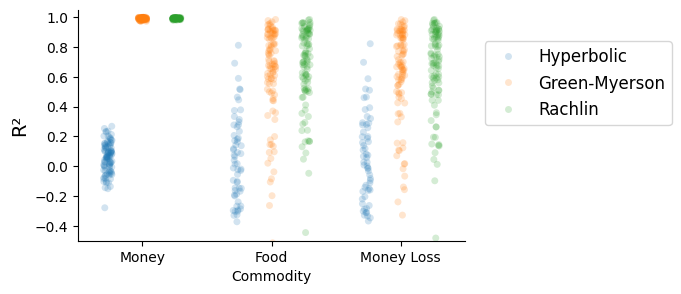

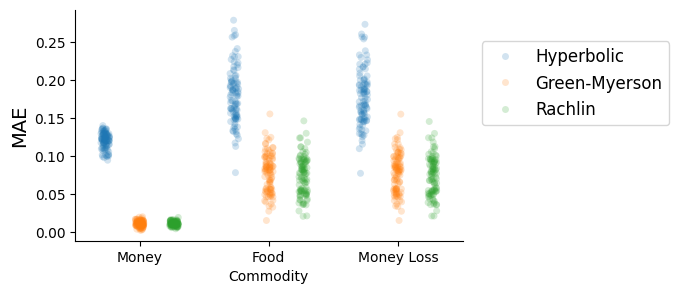

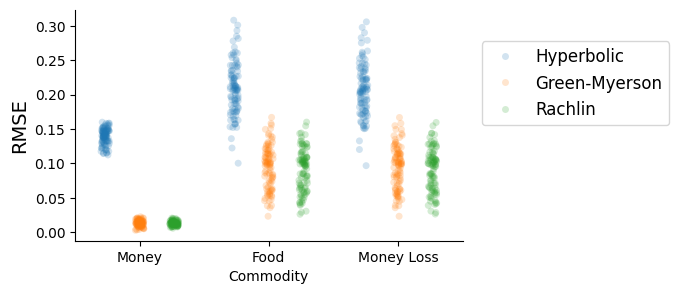

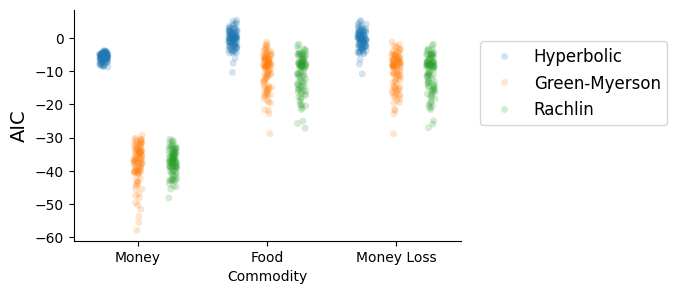

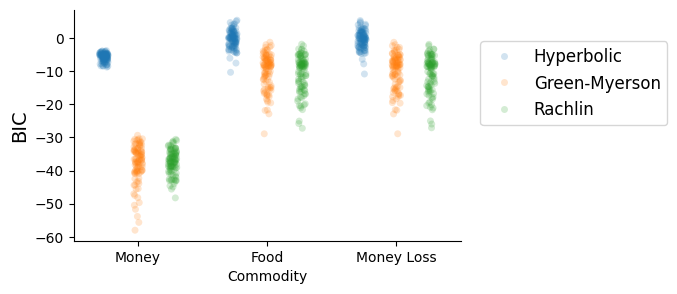

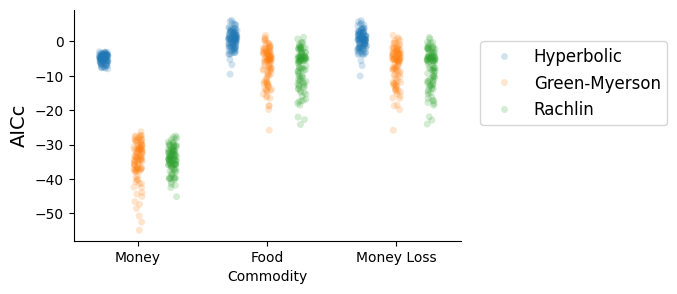

In [5]:
def plot_metric_comparison(summary_df, metric, ylim=None, figsize=(5, 3)):
    """
    Create a stripplot for comparing model performance across commodities for a specific metric.
    
    Parameters:
    - summary_df: DataFrame with model comparison results
    - metric: String name of the metric to plot (e.g., 'R²', 'MAE', 'RMSE', 'AIC', 'BIC', 'AICc')
    - ylim: Tuple of (min, max) for y-axis limits. If None, uses default scaling.
    - figsize: Tuple of (width, height) for figure size
    """
    # Prepare data
    metric_df = summary_df[['Commodity', 'Model', metric]].melt(
        id_vars=['Commodity', 'Model'], 
        var_name='Metric', 
        value_name='Value'
    )
    
    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.stripplot(x='Commodity', y='Value', hue='Model', data=metric_df, 
                  ax=ax, dodge=True, alpha=0.2)
    
    # Formatting
    ax.set_ylabel(metric, fontsize=14)
    ax.set_xlabel('Commodity')
    
    if ylim is not None:
        plt.ylim(ylim)
    
    sns.despine(top=True, right=True)
    plt.legend(loc=(1.05, 0.5), fontsize=12)
    plt.show()

# Create plots for each metric
metrics_to_plot = [
    ('R²', (-0.5, 1.05)),
    ('MAE', None),
    ('RMSE', None),
    ('AIC', None),
    ('BIC', None),
    ('AICc', None)
]

for metric, ylim in metrics_to_plot:
    plot_metric_comparison(summary_df, metric, ylim=ylim)

## Classification Task

In [6]:
# Make the data set
np.random.seed(80725)

n = 50000

df = pd.DataFrame({
    "SessionDuration": np.random.normal(60, 15, n).clip(30, 120),
    "StaffExperience": np.random.exponential(3, n).clip(0, 20),
    "PreviousIncidents": np.random.poisson(2, n),
    "InterventionInPlace": np.random.choice([0, 1], size=n, p=[0.3, 0.7]),
    "MedicationChange": np.random.choice([0, 1], size=n, p=[0.85, 0.15]),
    "Age": np.random.normal(10, 3, n).clip(3, 18)
})

# Simulate outcome with noisy logistic function
logits = (
    -1.0 + 
    0.03 * df["SessionDuration"] +
    -0.2 * df["StaffExperience"] +
    0.5 * df["PreviousIncidents"] +
    -0.8 * df["InterventionInPlace"] +
    1.2 * df["MedicationChange"] +
    0.05 * df["Age"]
)

prob = 1 / (1 + np.exp(-logits))
df["ChallengingBehavior"] = np.random.binomial(1, prob)
df.to_csv("challenging_behavior_data.csv", index=False)

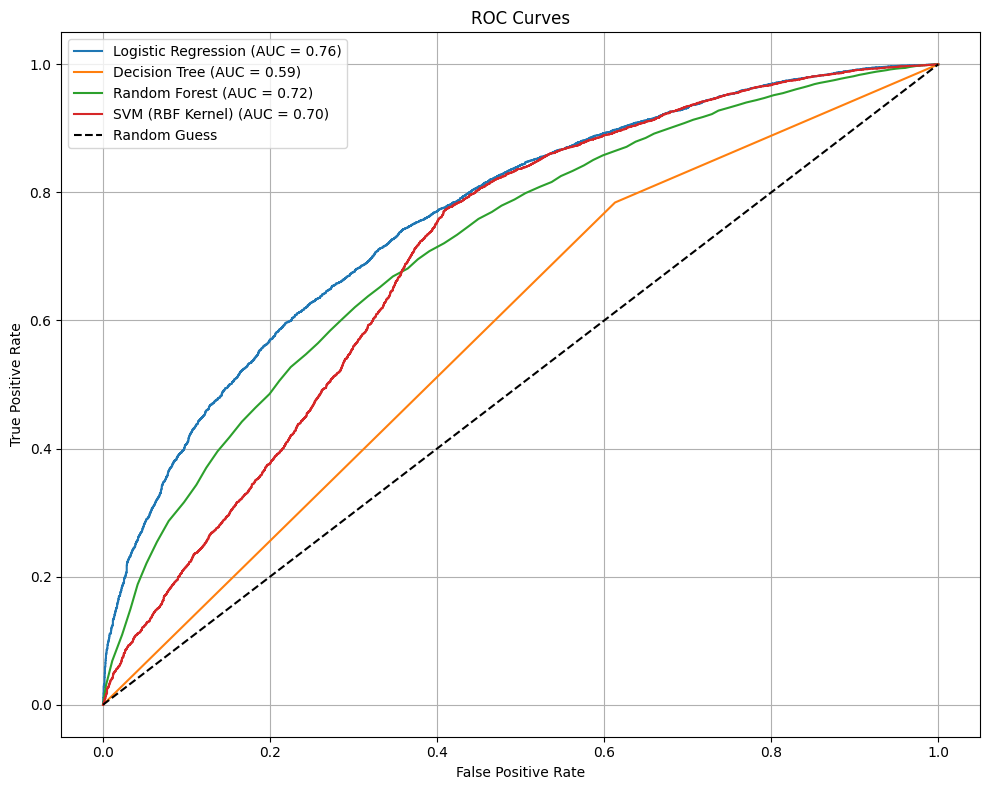

,Accuracy,Precision,Recall,F1 Score,MCC,ROC AUC
Model,,,,,,
Logistic Regression,0.766,0.785,0.937,0.854,0.306,0.764
Decision Tree,0.679,0.780,0.784,0.782,0.172,0.586
Random Forest,0.746,0.787,0.898,0.839,0.270,0.719
SVM (RBF Kernel),0.766,0.774,0.963,0.858,0.291,0.705


In [7]:
# One-hot encode any categorical columns (if applicable)
df = pd.get_dummies(df, drop_first=True)

# ---- Train/Test Split ----
X = df.drop("ChallengingBehavior", axis=1)
y = df["ChallengingBehavior"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---- Feature Scaling (optional, needed for some models) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Models ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

# ---- Evaluation ----
results = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Use scaled data for models that need it
    if "SVM" in name or "Logistic" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "MCC": mcc,
        "ROC AUC": roc_auc
    })

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ---- ROC Curve Plot ----
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Results Table ----
results_df = pd.DataFrame(results).set_index("Model").round(3)
display(results_df)
